# Entendimiento inicial de los datos

In [214]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from scipy.stats import chi2_contingency
import re
from datetime import datetime, timedelta
pd.set_option('display.max_columns', None)

In [215]:
tracking_df=pd.read_csv("maestra.csv")

C:\Users\Diego\AppData\Local\Temp\ipykernel_21112\2919470359.py:1: DtypeWarning: Columns (4,19,21,25) have mixed types. Specify dtype option on import or set low_memory=False.
  tracking_df=pd.read_csv("maestra.csv")


In [216]:
tracking_df=tracking_df[(tracking_df["duracion_real_total_tarea"] >= 0) & (tracking_df["id_registro_declaracion"].notnull())]

In [217]:
tracking_df.dtypes

Unnamed: 0                                 int64
tarea_id                                  object
creacion_tarea_grizzly                    object
is_subtarea                               object
parent_id                                 object
proyecto_id                               object
duracion_total_planeada_tarea            float64
duracion_real_total_tarea                float64
id_registro_declaracion                   object
fecha_registro_grizzly_empleado           object
fecha_tarea_empleado                      object
duracion_parcial_tarea                   float64
fuente                                    object
empleado_id                               object
creacion_proyecto_grizzly                 object
team_id                                   object
duracion_total_planeada_projecto         float64
duracion_real_total_projecto             float64
creacion_team_grizzly                     object
eliminacion_team_grizzly                  object
fecha_subcripcion_em

In [218]:
# #Bloque para hacer purebas
# B=tracking_df.groupby(["proyecto_id"]) \
#     .size() \
#     .sort_values(ascending=False)
# B[B == 5]

# example="ffafab1f-fc85-4188-8a2b-362149855550"
# A=tracking_df[ (tracking_df["proyecto_id"]==example)]
# A.head(5)

# A=tracking_df_temp[ (tracking_df_temp["proyecto_id"]==example)]
# A.head(100)

In [219]:
tracking_df_clean = (
    tracking_df
    .groupby(["proyecto_id", "team_id", "estado", "oferta"])
    .agg({
        "tarea_id": pd.Series.nunique,                       # count_distinct
        "id_registro_declaracion": pd.Series.nunique,        # count_distinct
        "fuente": lambda x: x.value_counts().idxmax(),      # moda
        "duracion_total_planeada_projecto": "max",
        "duracion_real_total_projecto": "max",
        "duracion_meses_team": "max",
    })
    .rename(columns={
        "tarea_id": "cantidad_tareas",
        "id_registro_declaracion": "num_seguimientos",
        "duracion_total_planeada_projecto":"duracion_planeada_total_projecto",
    })
    .reset_index()
)

In [220]:
print(tracking_df.shape)
print(tracking_df_clean.shape)

(4436742, 28)
(49506, 10)


- Se filtran las columnas que dan valor al modelo


In [221]:
cols_eliminar=["team_id","proyecto_id"]
tracking_df_clean=tracking_df_clean.drop(columns=cols_eliminar)

In [222]:
tracking_df_clean.head(2)

,estado,oferta,cantidad_tareas,num_seguimientos,fuente,duracion_planeada_total_projecto,duracion_real_total_projecto,duracion_meses_team
0,disabled,budget,1,38,app,40.0,40.00,NaN
1,active,time,9,36,app,0.0,54.75,NaN


- Se observa la distribucion de la columna objetivo "duracion_real_total_projecto"

In [223]:
tracking_df_clean["duracion_real_total_projecto"].skew()

np.float64(58.82873297457198)

Se observa una asimetria postiva en la variable. Por lo tanto se va a observar por intervalos de horas la cantidad de tareas que existen.

<Axes: xlabel='duracion_real_total_projecto'>

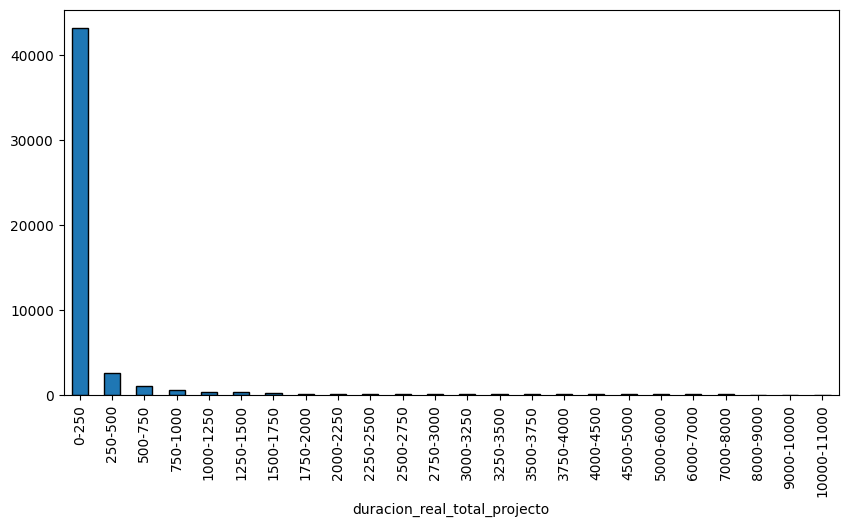

In [224]:
tareas=tracking_df_clean["duracion_real_total_projecto"]
bins=[0,250,500,750,1000,1250,1500,1750,2000,2250,2500,2750,3000,3250,3500,3750,4000,4500,5000,6000,7000,8000,9000,10000,11000]
labels=[
    "0-250",
    "250-500",
    "500-750",
    "750-1000",
    "1000-1250",
    "1250-1500",
    "1500-1750",
    "1750-2000",
    "2000-2250",
    "2250-2500",
    "2500-2750",
    "2750-3000",
    "3000-3250",
    "3250-3500",
    "3500-3750",
    "3750-4000",
    "4000-4500",
    "4500-5000",
    "5000-6000",
    "6000-7000",
    "7000-8000",
    "8000-9000",
    "9000-10000",
    "10000-11000"
]
rangos=pd.cut(tareas,bins=bins,labels=labels,include_lowest=True)
frecuencias=rangos.value_counts().sort_index()
plt.figure(figsize=(10,5))
frecuencias.plot(kind="bar",edgecolor="black")

In [225]:
rangos.value_counts(normalize=True,dropna=False).sort_index()*100

duracion_real_total_projecto
0-250          87.203571
250-500         5.148871
500-750         2.092676
750-1000        1.183695
1000-1250       0.725165
1250-1500       0.608007
1500-1750       0.349453
1750-2000       0.298954
2000-2250       0.222195
2250-2500       0.183816
2500-2750       0.185836
2750-3000       0.123217
3000-3250       0.096958
3250-3500       0.090898
3500-3750       0.103018
3750-4000       0.092918
4000-4500       0.123217
4500-5000       0.115138
5000-6000       0.197956
6000-7000       0.169676
7000-8000       0.092918
8000-9000       0.076758
9000-10000      0.052519
10000-11000     0.048479
NaN             0.414091
Name: proportion, dtype: float64

Con base a los intervalos observados, se va a limitar la variable tarjet entre un rango de mas de 1h hasta menos de 250 horas

In [226]:
tracking_df_clean=tracking_df_clean[(tracking_df_clean["duracion_real_total_projecto"]>0) & (tracking_df_clean["duracion_real_total_projecto"]<=250)]

- se grafica nuevamente la variable en los intervalos

<Axes: xlabel='duracion_real_total_projecto'>

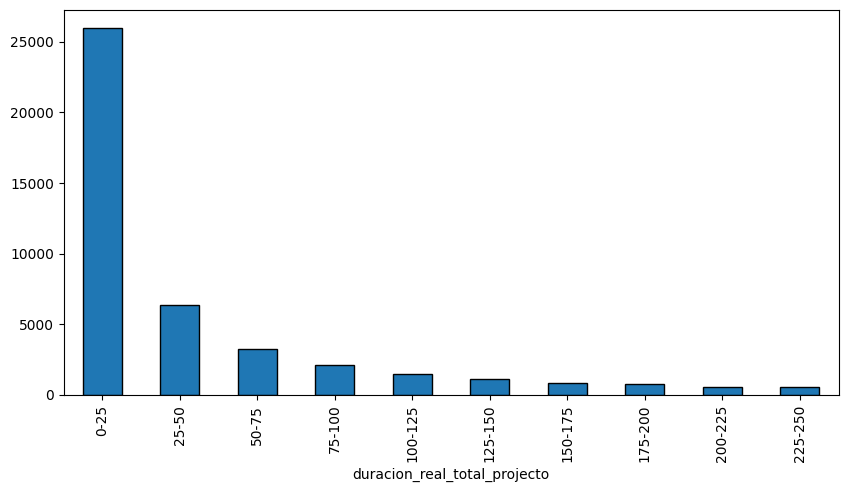

In [227]:
tareas=tracking_df_clean["duracion_real_total_projecto"]
bins=[0,25,50,75,100,125,150,175,200,225,250]
labels=[
    "0-25",
    "25-50",
    "50-75",
    "75-100",
    "100-125",
    "125-150",
    "150-175",
    "175-200",
    "200-225",
    "225-250"
]
rangos=pd.cut(tareas,bins=bins,labels=labels,include_lowest=True)
frecuencias=rangos.value_counts().sort_index()
plt.figure(figsize=(10,5))
frecuencias.plot(kind="bar",edgecolor="black")

- haciendo un analisis mas a detalle, entre el rango de 0 a 250 h, se observa que la mayoria de proyecto estan entre 0 y 25 horas por lo que el filtro final para la variable de duracion real proyecto sera el intervalo mencionado

In [228]:
tracking_df_clean=tracking_df_clean[(tracking_df_clean["duracion_real_total_projecto"]>0) & (tracking_df_clean["duracion_real_total_projecto"]<=25)]

{'whiskers': [<matplotlib.lines.Line2D at 0x1d99dc7d450>,
 'caps': [<matplotlib.lines.Line2D at 0x1d9681313d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d97eaec2d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1d968133610>],
 'fliers': [<matplotlib.lines.Line2D at 0x1d9681325d0>],
 'means': []}

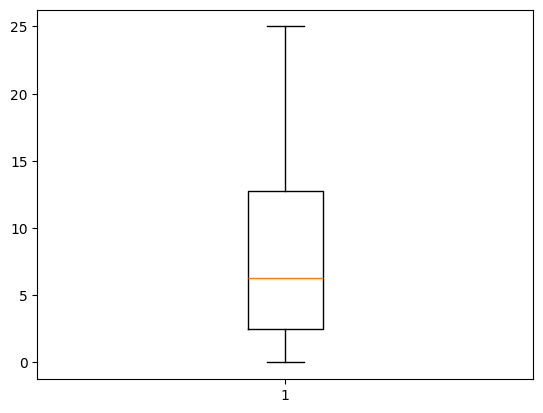

In [229]:
plt.boxplot(tracking_df_clean["duracion_real_total_projecto"])

In [230]:
tracking_df_clean.shape

(25946, 8)

- Analisis variable "cantidad_tareas": se limita a 25 que es el numero maximo de distintas tareas que se pueden tener para proyectos reales de 25 horas

In [231]:
tracking_df_clean["cantidad_tareas"]=tracking_df_clean["cantidad_tareas"].clip(upper=25)

- Analisis variable "num_seguimientos": se limita la variable a 25 debido a que es el numero maximo de  seguimientos que se puede tener de una hora para proyectos que demoraron 25 horas

In [232]:
tracking_df_clean["num_seguimientos"]=tracking_df_clean["num_seguimientos"].clip(upper=25)

- Analisis variable "duracion_planeada_total_projecto"

In [233]:

tracking_df_clean["duracion_planeada_total_projecto"].describe()

count     25946.000000
mean         32.916775
std         748.323897
min           0.000000
25%           0.000000
50%           0.000000
75%           8.000000
max      100000.000000
Name: duracion_planeada_total_projecto, dtype: float64

Se observa que el valor maximo es 625, por lo tanto se considera un valor outlier porque una estimacion no deberia ser 25 veces mayor a la real. Por lo tanto, se limita a que la estimacion puede ser hasta 4 veces mayor que la estimacion real, es decir, hasta 100 horas.


In [234]:
tracking_df_clean["duracion_planeada_total_projecto"]=tracking_df_clean["duracion_planeada_total_projecto"].clip(upper=100)

{'whiskers': [<matplotlib.lines.Line2D at 0x1d995b13910>,
 'caps': [<matplotlib.lines.Line2D at 0x1d995b12510>,
 'boxes': [<matplotlib.lines.Line2D at 0x1d98d44c810>],
 'medians': [<matplotlib.lines.Line2D at 0x1d995b10810>],
 'fliers': [<matplotlib.lines.Line2D at 0x1d995b10b50>],
 'means': []}

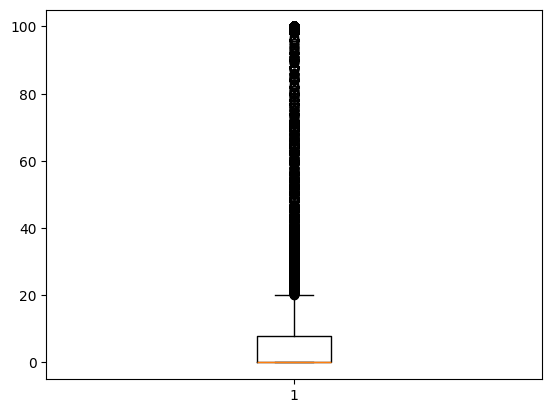

In [235]:
#tracking_df_clean["duracion_planeada_total_projecto"].isna().sum()
#tracking_df_clean["duracion_planeada_total_projecto"].describe()
plt.boxplot(tracking_df_clean["duracion_planeada_total_projecto"])

- Se analiza variable "duracion_meses_team": Se calcula que el tiempo de ejecucion para un proyecto de 25 h (intervalo de interes) es cerca de una 4 si se trabaja 8 horas cada dia. Se limita a que el tiempo estimado del proyecto pueda ser hasta 10 veces el real, es decir, 40 dias que son 2 meses. Por lo tanto, se limita duracion_meses_team a 2 meses. Por otro lado,se tiene cerca del 71% de valores en NAN, por lo que se imputa con la media.

In [238]:
tracking_df_clean["duracion_meses_team"].describe()

count    7668.000000
mean       23.335942
std        15.740629
min         2.000000
25%         8.000000
50%        19.000000
75%        33.000000
max        76.000000
Name: duracion_meses_team, dtype: float64

In [240]:
tracking_df_clean["duracion_meses_team"]=tracking_df_clean["duracion_meses_team"].clip(upper=2)

In [241]:
tracking_df_clean["duracion_meses_team"]=tracking_df_clean["duracion_meses_team"].fillna(tracking_df_clean["duracion_meses_team"].mean())

In [246]:
for x in tracking_df_clean.columns:
    try:
        print(x,"   ",tracking_df_clean[x].skew())
    except:
        print(x,"   ","No se pudo")
        pass

estado     No se pudo
oferta     No se pudo
cantidad_tareas     2.9337347687648334
num_seguimientos     1.507300769140391
fuente     No se pudo
duracion_planeada_total_projecto     2.697146732395351
duracion_real_total_projecto     0.8074950367010127
duracion_meses_team     0.0


In [247]:
tracking_df_clean.shape

(25946, 8)